# Assignment 1

Deadline: 19.03.2026, 12:00 CET

<Ryan Yo | 25-712-373 | ryan.yo@uzh.ch>

In [36]:
# Import standard libraries
import os
import sys
import timeit # To compute runtimes
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Import local modules ---

# 1. Get the directory where your notebook is (the 'assignments' folder)
current_dir = os.getcwd()

# 2. Go up one level to the 'qpmwp-course' folder
project_root = os.path.dirname(current_dir)

# 3. Point specifically to the 'src' folder where the modules live
src_path = os.path.join(project_root, 'src')

# 4. Add the project root and src to Python's search path
if project_root not in sys.path:
    sys.path.append(project_root)
if src_path not in sys.path:
    sys.path.append(src_path)

# Now these imports will find the folders inside 'src'
from estimation.covariance import Covariance, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
from helper_functions import simulate_correlated_gbm

## 1. Solver Horse Race

### 1.a)
(3 points)

Generate a synthetic dataset of dimension TxN, T=1000, N=50, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [37]:

# Set the dimensions
T = 1000       # Number of time steps
N = 50         # Number of assets
rnd_seed = 42  # Random seed for reproducibility

# Set random seed for reproducibility
np.random.seed(rnd_seed)

# Generate a random mean vector and covariance matrix.
# Make sure the covariance matrix is positive definite.

mu = np.random.normal(loc=0.05, scale=0.2, size=N)
random_matrix = np.random.randn(N, N)
sigma = np.dot(random_matrix, random_matrix.T)
sigma = make_pos_def(sigma)

# Generate correlated geometric Brownian motion paths and compute discrete returns
prices = simulate_correlated_gbm(mu=mu, sigma=sigma, T=T, random_seed=None)
returns = prices.pct_change().dropna()

# Compute the vector of expected returns from df using class ExpectedReturn
er = ExpectedReturn()
er.estimate(X=returns)
q = er.vector

# Compute the covariance matrix from df using class Covariance
cov = Covariance()
cov.estimate(X=returns)
P = cov.matrix


# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Vector of expected returns (q):
Asset_1    -0.006753
Asset_2    -0.026953
Asset_3    -0.024547
Asset_4    -0.027265
Asset_5    -0.031752
Asset_6    -0.016928
Asset_7    -0.029836
Asset_8    -0.028190
Asset_9    -0.031084
Asset_10   -0.022388
Asset_11   -0.027769
Asset_12   -0.028333
Asset_13   -0.032432
Asset_14   -0.034891
Asset_15   -0.026469
Asset_16   -0.015509
Asset_17   -0.011275
Asset_18   -0.030683
Asset_19   -0.030011
Asset_20   -0.021558
Asset_21   -0.018261
Asset_22   -0.016048
Asset_23   -0.037413
Asset_24   -0.026599
Asset_25   -0.024838
Asset_26   -0.020495
Asset_27   -0.019487
Asset_28   -0.015049
Asset_29   -0.020391
Asset_30   -0.030757
Asset_31   -0.034418
Asset_32   -0.040135
Asset_33   -0.024126
Asset_34   -0.018092
Asset_35   -0.027216
Asset_36   -0.029217
Asset_37   -0.012446
Asset_38   -0.028647
Asset_39   -0.038146
Asset_40   -0.029296
Asset_41   -0.029003
Asset_42   -0.025123
Asset_43   -0.027295
Asset_44   -0.027669
Asset_45   -0.013155
Asset_46   -0.018646
As

### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the return series created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 15 assets is <= 0.3, the sum of assets 16 to 45 is <= 0.4 and the sum of assets 41 to 50 is <= 0.5

In [38]:
# Instantiate the Constraints class
constraints = Constraints(ids = returns.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='==')

# Add box constraints (i.e., lower and upper bounds)
constraints.add_box('LongOnly', lower=0.0, upper=0.2) # long-only with max 20% allocation per asset

# Add linear constraints
# Group 1: Assets 1-15 (sum <= 0.3)
g1_values = pd.Series(1, index=returns.columns[0:15])
constraints.add_linear(g_values = g1_values, sense='<=', rhs=0.3, name='group_1')

# Group 2: Assets 16-45 (sum <= 0.4)
g2_values = pd.Series(1, index=returns.columns[15:45])
constraints.add_linear(g_values = g2_values, sense='<=', rhs=0.4, name='group_2')

# Group 3: Assets 41-50 (sum <= 0.5)
g3_values = pd.Series(1, index=returns.columns[40:50])
constraints.add_linear(g_values = g3_values, sense='<=', rhs=0.5, name='group_3')

# Display some columns of the G matrix to verify that the constraints have been set up correctly
constraints.linear['G'][['Asset_1', 'Asset_15', 'Asset_16', 'Asset_40', 'Asset_41', 'Asset_50']]

,Asset_1,Asset_15,Asset_16,Asset_40,Asset_41,Asset_50
group_1,1.0,1.0,0.0,0.0,0.0,0.0
group_2,0.0,0.0,1.0,1.0,1.0,0.0
group_3,0.0,0.0,0.0,0.0,1.0,1.0


### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers that you could install and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constraints fulfilled? Extract primal residuals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers where the optimization failed for some reason.




In [46]:
GhAb = constraints.to_GhAb()
lb = constraints.box['lower'].to_numpy()
ub = constraints.box['upper'].to_numpy()

# qpsolvers minimizes 0.5 x'Px + q'x, so P = 2*Sigma and q = -mu for mean-variance
P_obj = 2 * P.to_numpy()
q_obj = -q.to_numpy()

results_dict = {}

for solver_name in sorted(USABLE_SOLVERS):
    try:
        qp = QuadraticProgram(
            P=P_obj, q=q_obj,
            G=GhAb['G'], h=GhAb['h'],
            A=GhAb['A'], b=GhAb['b'],
            lb=lb, ub=ub,
            solver=solver_name,
        )
        runtime = timeit.timeit(lambda: qp.solve(), number=1)
        sol = qp.results['solution']
        results_dict[solver_name] = {
            'solution_found': sol.found,
            'objective': qp.objective_value() if sol.found else np.nan,
            'primal_residual': sol.primal_residual() if sol.found else np.nan,
            'dual_residual': sol.dual_residual() if sol.found else np.nan,
            'duality_gap': sol.duality_gap() if sol.found else np.nan,
            'runtime': runtime,
        }
    except Exception as e:
        print(f"{solver_name} failed: {e}")
        results_dict[solver_name] = {
            'solution_found': False,
            'objective': np.nan,
            'primal_residual': np.nan,
            'dual_residual': np.nan,
            'duality_gap': np.nan,
            'runtime': np.nan,
        }

df_results = pd.DataFrame(results_dict)
df_results

,cvxopt,daqp,osqp,qpalm,quadprog
solution_found,True,True,True,True,True
objective,0.0,0.0,-0.000163,-0.0,-0.0
primal_residual,0.0,0.0,0.000439,0.0,0.0
dual_residual,0.0,0.0,0.000003,0.0,0.0
duality_gap,0.0,0.0,0.000163,0.0,0.0
runtime,0.004111,0.001011,0.003102,0.002018,0.001315


Print and visualize the results

                   cvxopt      daqp      osqp     qpalm  quadprog
solution_found       True      True      True      True      True
objective             0.0       0.0 -0.000163      -0.0      -0.0
primal_residual       0.0       0.0  0.000439       0.0       0.0
dual_residual         0.0       0.0  0.000003       0.0       0.0
duality_gap           0.0       0.0  0.000163       0.0       0.0
runtime          0.004111  0.001011  0.003102  0.002018  0.001315


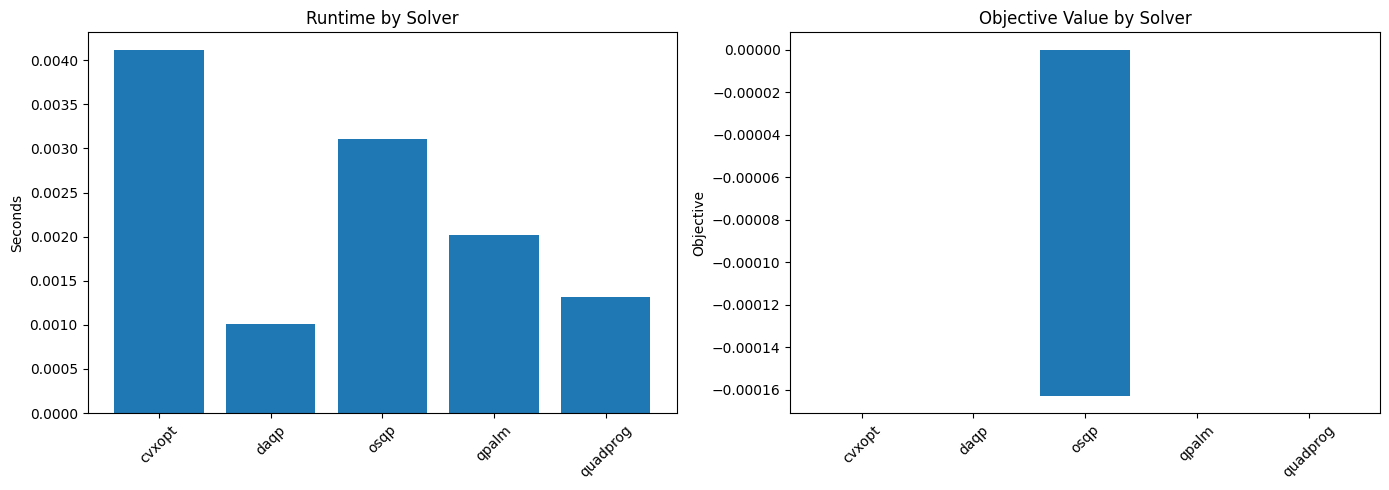

In [47]:
print(df_results.to_string())

successful = df_results.loc[:, df_results.loc['solution_found'] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(successful.columns, successful.loc['runtime'].astype(float))
axes[0].set_title('Runtime by Solver')
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(successful.columns, successful.loc['objective'].astype(float))
axes[1].set_title('Objective Value by Solver')
axes[1].set_ylabel('Objective')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


In [41]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        # <your code here>

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            asset_names = Sigma.columns
            Sigma_np = Sigma.to_numpy()
            return None
        else:
            return super().solve()


# Create a constraints object with just a budget constraint
# <your code here>

# Instantiate the MinVariance class
# <your code here>

# Prepare the optimization data and prepare the optimization problem
# <your code here>

# Solve the optimization problem and print the weights
# <your code here>

IndentationError: expected an indented block after function definition on line 14 (3911343723.py, line 17)

In [48]:
class MinVariance(Optimization):

    def __init__(self, constraints, covariance=None, **kwargs):
        super().__init__(constraints=constraints, **kwargs)
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data):
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        self.objective = Objective(
            q=np.zeros(X.shape[1]),
            P=covmat * 2,
        )

    def solve(self):
        if self.params.get('solver_name') == 'analytical':
            # w* = Sigma^{-1} 1 / (1' Sigma^{-1} 1)
            Sigma = self.objective.coefficients['P'] / 2
            if isinstance(Sigma, pd.DataFrame):
                Sigma = Sigma.to_numpy()
            Sigma_inv = np.linalg.inv(Sigma)
            ones = np.ones(Sigma.shape[0])
            w_star = (Sigma_inv @ ones) / (ones @ Sigma_inv @ ones)
            self.results.update({
                'weights': pd.Series(w_star, index=self.constraints.ids).to_dict(),
                'status': True,
            })
        else:
            return super().solve()


constraints_mv = Constraints(ids=returns.columns.tolist())
constraints_mv.add_budget(rhs=1, sense='=')

min_var = MinVariance(constraints=constraints_mv, covariance=Covariance(), solver_name='analytical')
opt_data = OptimizationData(return_series=returns, align=False)
min_var.set_objective(optimization_data=opt_data)
min_var.solve()

w_analytical = pd.Series(min_var.results['weights'])
print(w_analytical)
print("\nsum:", round(w_analytical.sum(), 6))

# Compare to numerical solution
min_var_num = MinVariance(constraints=constraints_mv, covariance=Covariance(), solver_name='cvxopt')
min_var_num.set_objective(optimization_data=opt_data)
min_var_num.solve()
w_numerical = pd.Series(min_var_num.results['weights'])

print("\nMax abs difference vs cvxopt:", (w_analytical - w_numerical).abs().max())

Asset_1     0.046497
Asset_2     0.011182
Asset_3    -0.059411
Asset_4    -0.022466
Asset_5     0.020378
Asset_6     0.087554
Asset_7     0.019796
Asset_8    -0.005684
Asset_9     0.049368
Asset_10    0.021778
Asset_11   -0.038915
Asset_12    0.013499
Asset_13   -0.000772
Asset_14    0.011445
Asset_15    0.021803
Asset_16    0.039245
Asset_17    0.023610
Asset_18   -0.018442
Asset_19    0.051703
Asset_20   -0.011554
Asset_21    0.043036
Asset_22    0.024005
Asset_23    0.020261
Asset_24    0.020436
Asset_25    0.027719
Asset_26    0.032939
Asset_27    0.019057
Asset_28    0.021534
Asset_29    0.061274
Asset_30    0.006580
Asset_31    0.072461
Asset_32    0.000774
Asset_33    0.014786
Asset_34   -0.007299
Asset_35   -0.018446
Asset_36    0.057174
Asset_37    0.025243
Asset_38    0.067535
Asset_39    0.035452
Asset_40    0.013950
Asset_41    0.000755
Asset_42    0.005604
Asset_43   -0.001433
Asset_44    0.089231
Asset_45   -0.008050
Asset_46   -0.012307
Asset_47    0.038974
Asset_48    0